# ___Geographical data visualizations___
----------------

In [2]:
!python --version

Python 3.13.7


The system cannot find the path specified.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
with open(file=r"../../data/maps/australia-borders-coordinates.npy", mode="rb") as fp:
    aus_border = np.load(fp)

# Themeda soil site data from Emma
themeda = pd.read_csv(r"../../data/chapter3/CSBP_soil_analysis_Themeda_and_Sorghum.csv", skiprows=range(20, 35)).drop(0, axis=0)
themeda = themeda.rename(mapper= lambda name: name.lower().strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'prcnt'), axis=1)
themeda = themeda.astype({"total_nitrogen": np.float64, "total_phosphorus": np.float64, "total_carbon": np.float64, "prcnt_clay": np.float64, "prcnt_course_sand": np.float64, "prcnt_fine_sand": np.float64, "prcnt_sand": np.float64, "prcnt_silt": np.float64})
CHOSEN_SITES = ("TT4", "TT6", "TT7", "TT13", "TT15", "TT17")
themeda_subset = themeda.query("customer_sample_id.isin(@CHOSEN_SITES)")

# Themeda seed site data from Vin
themeda_seeds = pd.read_csv(r"../../data/chapter3/themeda_seed_coords_vin.csv")
# Meteorology data hand scraped by me on 28-08-2025 from BoM
meterology = pd.read_csv(r"../../data/chapter3/site_metereology.csv", header=2).drop(index=[2, 3]).reset_index(drop=True)
# Themeda AMF reculturing data from Jay
jay = pd.read_csv(r"../../../Jay/site data.csv", usecols=("Site", "latitude", "longitude", "date", "Genus", "Species", "Site_code")).query(r"Genus=='Themeda'")

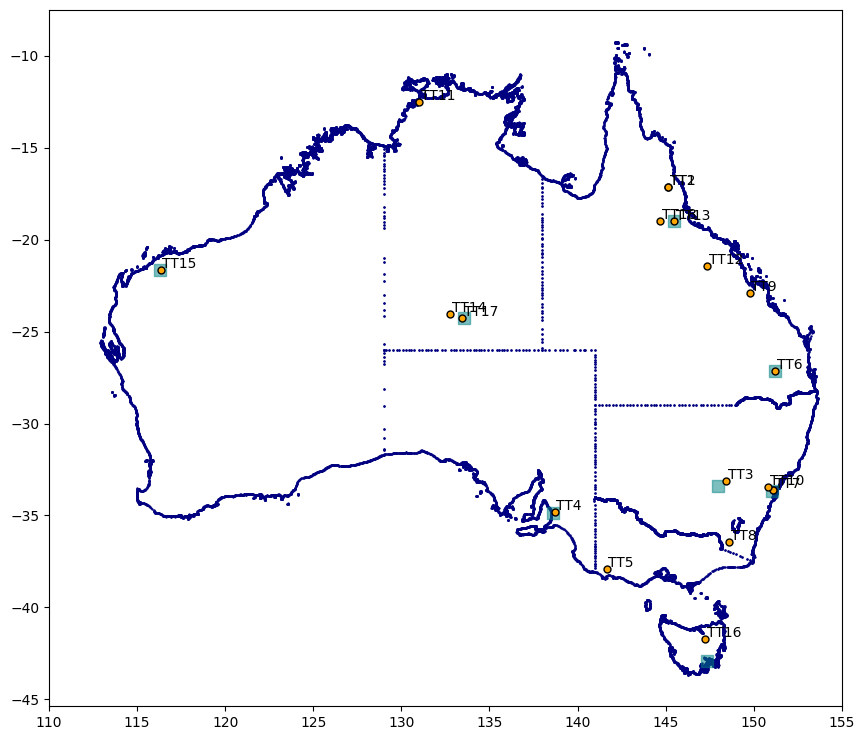

In [5]:
fig, axes = plt.subplots()
fig.set_size_inches(8.75, 7.5)
axes.scatter(aus_border[:, 0], aus_border[:, 1], color="navy", s=0.5)
for (_, (sample, lat, long)) in themeda.loc[:, ["customer_sample_id", "latitude", "longitude"]].iterrows():
    axes.plot(long, lat, label=sample, marker='o', markersize=5, markeredgecolor="black", markerfacecolor="orange", linestyle="none")
    axes.text(x=long+.1, y=lat+.1, s=sample, color="black")

axes.scatter(themeda_seeds.longitude, themeda_seeds.latitude, edgecolor="teal", facecolor="teal", s=70, marker='s', alpha=0.51)

axes.set_xlim(110, 155)
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/emma_vin_themeda_locations.jpeg", format="jpeg", dpi=500)

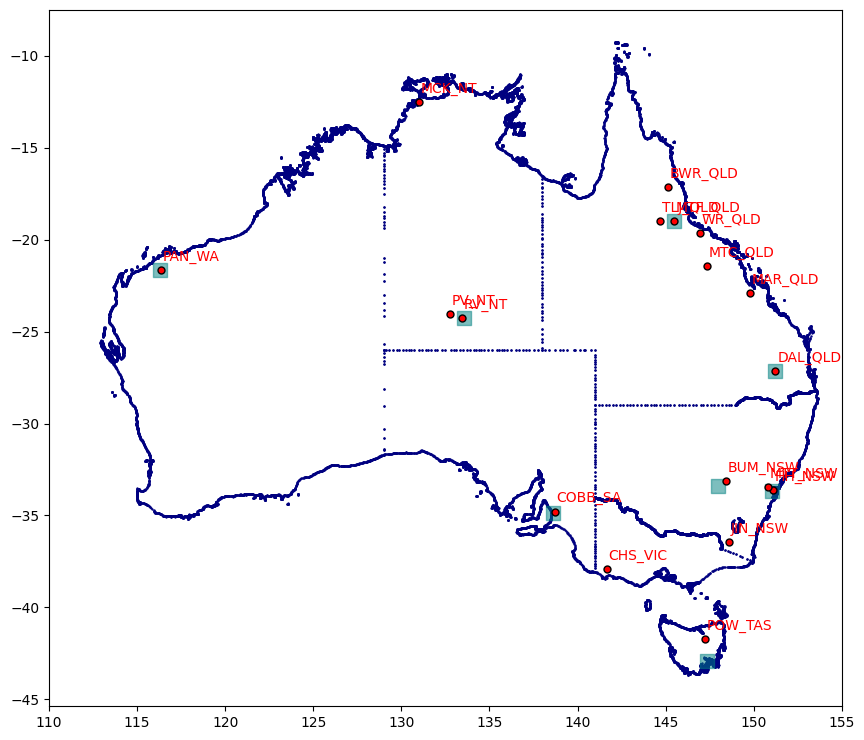

In [7]:
fig, axes = plt.subplots()
fig.set_size_inches(8.75, 7.5)
axes.scatter(aus_border[:, 0], aus_border[:, 1], color="navy", s=0.5)

# for (_, (sample, lat, long)) in themeda.loc[:, ["customer_sample_id", "latitude", "longitude"]].iterrows():
#     axes.plot(long, lat, label=sample, marker='o', markersize=5, markeredgecolor="black", markerfacecolor="orange", linestyle="none")
#     axes.text(x=long+.1, y=lat+.1, s=sample, color="black")

axes.scatter(themeda_seeds.longitude, themeda_seeds.latitude, edgecolor="teal", facecolor="teal", s=100, marker='s', alpha=0.51)

for (_, (lat, long, code)) in jay.loc[:, ["latitude", "longitude", "Site_code"]].iterrows():
    axes.plot(long, lat, label=sample, marker='o', markersize=5, markeredgecolor="black", markerfacecolor="red", linestyle="none")
    axes.text(x=long+.1, y=lat+.5, s=code, color="red")
    
axes.set_xlim(110, 155)
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/jay.png", dpi=800)